<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پنهان‌کاری
</font>
</h1>

In [1]:
# import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم تا دو تصویر را با همدیگر ترکیب کنیم. یک تصویر پس‌زمینه است و تصویر دیگر یک پیام است. ما قصد داریم تا این پیام را در تصویر پنهان کنیم. در ادامه مرحله به مرحله پیش خواهیم رفت تا در نهایت بتوانیم این متن را در تصویر جانشانی کنیم.
</font>
</p>

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصاویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصاویری که در پوشه Data قرار دارند را وارد کنید.
<br>
این تصویر پیش‌زمینه است:
<br>
cover.png
<br>
این تصویری نیز متنی است که قرار است در نهایت در تصویر پنهان شود:
<br>
msg.png
</font>
</p>

In [2]:
# load message/ cover images
msg = cv2.imread("Data/msg.png")    
msg = cv2.cvtColor(msg, cv2.COLOR_BGR2GRAY)

cover = cv2.imread("Data/cover.png")  
cover = cv2.cvtColor(cover, cv2.COLOR_BGR2GRAY)

In [3]:
# function to show images 
def imshow(image, *args, **kwargs):
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    plt.imshow(image, *args, **kwargs)
    plt.rcParams["figure.figsize"] = (5, 5)
    plt.axis('off')
    plt.show()

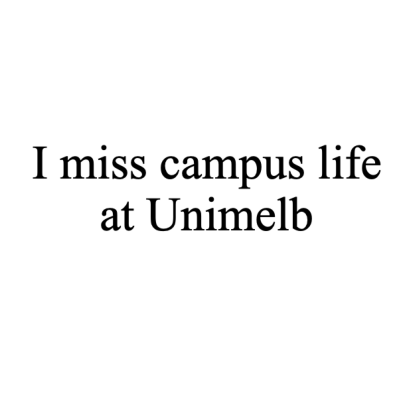

(580, 580) uint8


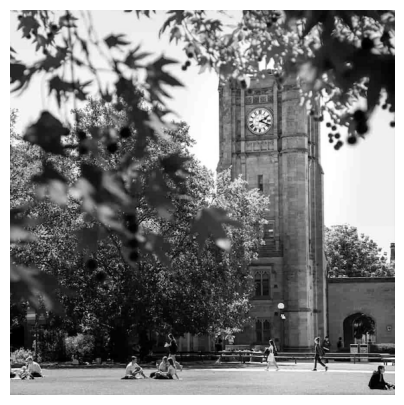

(580, 580) uint8


In [49]:
# check the size of images and visualise them
imshow(msg, cmap = 'gray')
print(msg.shape, msg.dtype)

imshow(cover, cmap = 'gray')
print(cover.shape, cover.dtype)


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: اعمال فیلتر بالاگذر بر پیام
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این قسمت قرار است که یک فیلتر بالاگذر گاوسی را بر تصویر پیغام اعمال کنیم.  دقت کنید که فرکانس قطع را بدرستی انتخاب کنید. ممکن است پس از مراحل پایانی برای افزایش کیفیت به این مرحله بازگردید و فیلتر را با فرکانس قطع متفاوتی مجددا اعمال کنید.
<br>
پس از اعمال فیلتربالاگذر گاوسی در این مرحله باید متن‌ در تصویر واضح شود(همانند اینکه متن لبه‌ای در تصویر است) . 
</font>
<br>
پیشنهاد می‌شود که از آستانه‌های پیشنهادی زیر برای این فیلتر بالاگذر استفاده کنید و از بین آن‌ها بهترین آستانه را انتخاب کنید:
</p>

$$\text{thresholds\_high} = [10, 25, 50, 100, 150, 200, 500]$$

In [50]:
# Gaussian highpass filter
def Gauss_HighPass(f,radius_high):   
    
    m = f.shape[0]
    n = f.shape[1]
    mask = np.zeros((m, n))
    
    x0 = np.floor(m/2)
    y0 = np.floor(n/2)
    for i in range(m):
        for j in range(n):
            dis = np.sqrt((i - x0)**2 + (j - y0)**2)
            mask[i][j] = 1-np.exp((-1)*dis**2/2/(radius_high**2))    
    
    result = np.multiply(f, mask) 
    return result,mask

# Gaussian lowpass filter
def Gauss_LowPass(f,radius_low):        
    
    m = f.shape[0]
    n = f.shape[1]
    mask = np.zeros((m, n))
  
    x0 = np.floor(m/2)
    y0 = np.floor(n/2)
    for i in range(m):
        for j in range(n):
            dis = np.sqrt((i - x0)**2 + (j - y0)**2)
            mask[i][j] = np.exp((-1)*dis**2/2/(radius_low**2))
        
    result = np.multiply(f, mask) 
    return result,mask

In [51]:
# For quantitative analysis
# the code is from https://www.pyimagesearch.com/2014/09/15/python-compare-two-images/

# the 'Mean Squared Error'; the lower the error, the more "similar"
def mse(imageA, imageB):
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])
    return err

# compute the mean squared error and structural similarity
def compare_images(imageA, imageB):
    # Calculate data range (max possible value range)
    data_range = max(imageA.max() - imageA.min(), imageB.max() - imageB.min())
    
    m = mse(imageA, imageB)
    s = ssim(imageA, imageB, 
             data_range=data_range,
             win_size=3) 
    
    print(f"MSE: {m:.2f}, SSIM: {s:.2f} (data_range: {data_range:.2f})")
    

#### High Pass Filter 

In [52]:
# frequency thresholds 
thresholds_high = [10, 25, 50, 100, 150, 200, 500]

# Fourier transform 
f_h = np.fft.fft2(msg)
f_h = np.fft.fftshift(f_h)

In [ ]:
# create an image filtered by maximum value for comparison
c_f_high_filtered, c_mask_high = Gauss_HighPass(f_h, 500)
c_high = np.real(np.fft.ifft2(np.fft.fftshift(c_f_high_filtered)))

In [ ]:
def Images_HighPass(radius_high):
    f_high_filtered, mask_high = Gauss_HighPass(f_h, radius_high)
    # Invert Fourier transform to get the filtered image
    img_high = np.real(np.fft.ifft2(np.fft.fftshift(f_high_filtered)))
    
    # visualisation setup
    fig, axs = plt.subplots(1, 2, figsize=(10, 10))
    
    print("Threshold ", radius_high)
    
    # Calculate data range for floating point images
    compare_images(c_high, img_high) 
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_high, cmap='gray', vmin=img_high.min(), vmax=img_high.max())  
    plt.title('high out')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask_high, cmap='gray')  
    plt.title('high mask')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


Threshold  10
MSE: 1330.43, SSIM: 0.81 (data_range: 338.62)


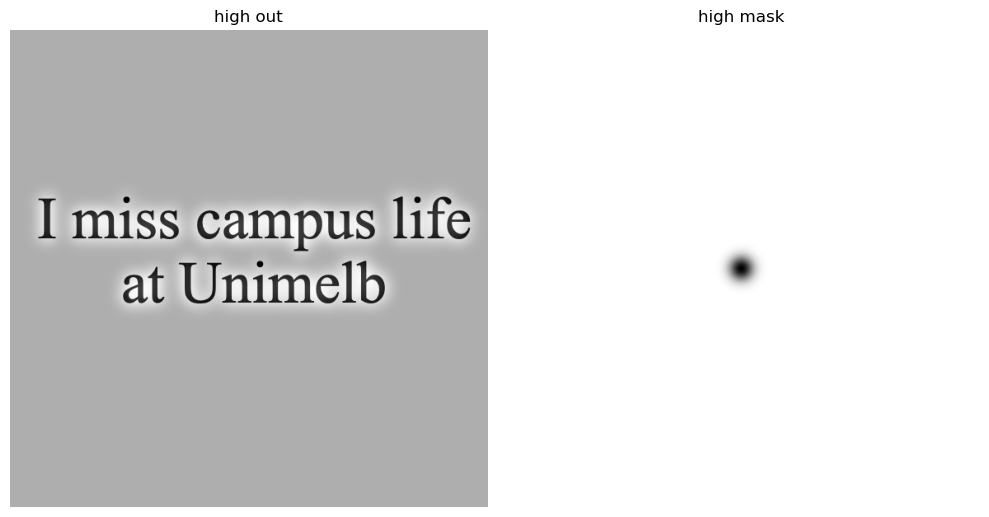

Threshold  25
MSE: 701.40, SSIM: 0.87 (data_range: 369.47)


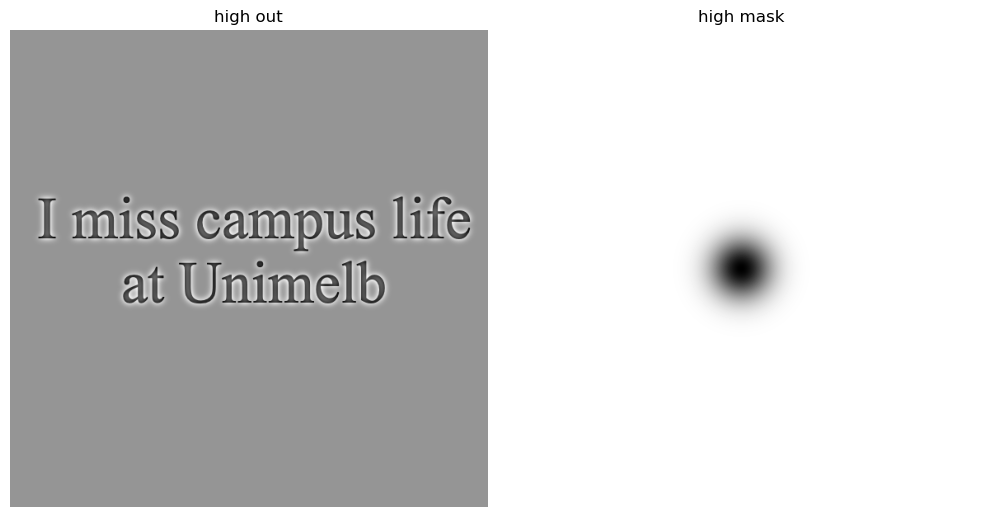

Threshold  50
MSE: 273.60, SSIM: 0.90 (data_range: 349.64)


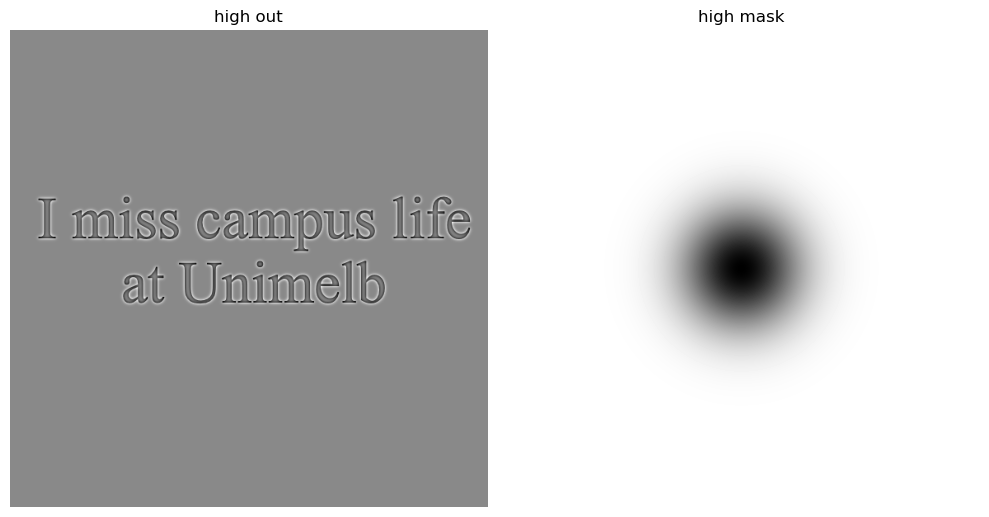

Threshold  100
MSE: 78.34, SSIM: 0.93 (data_range: 261.75)


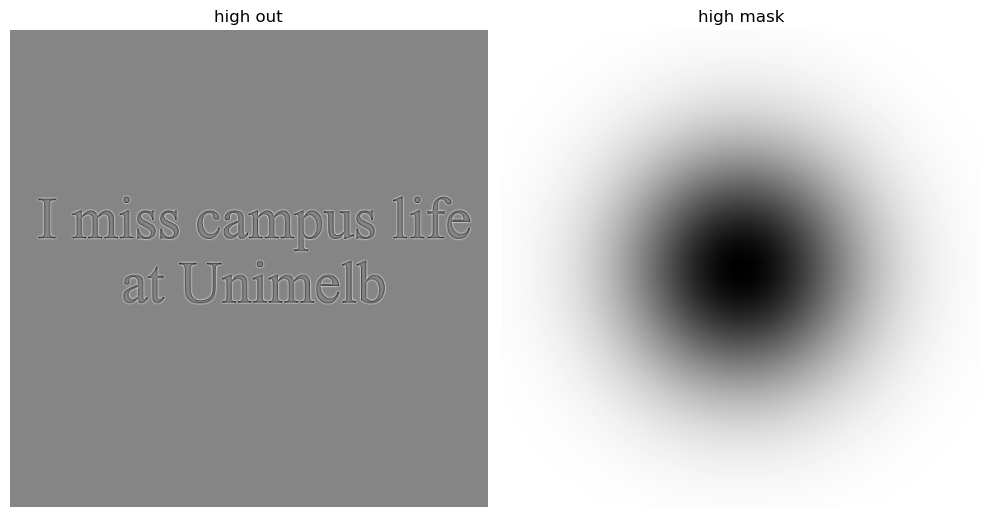

Threshold  150
MSE: 28.03, SSIM: 0.94 (data_range: 187.68)


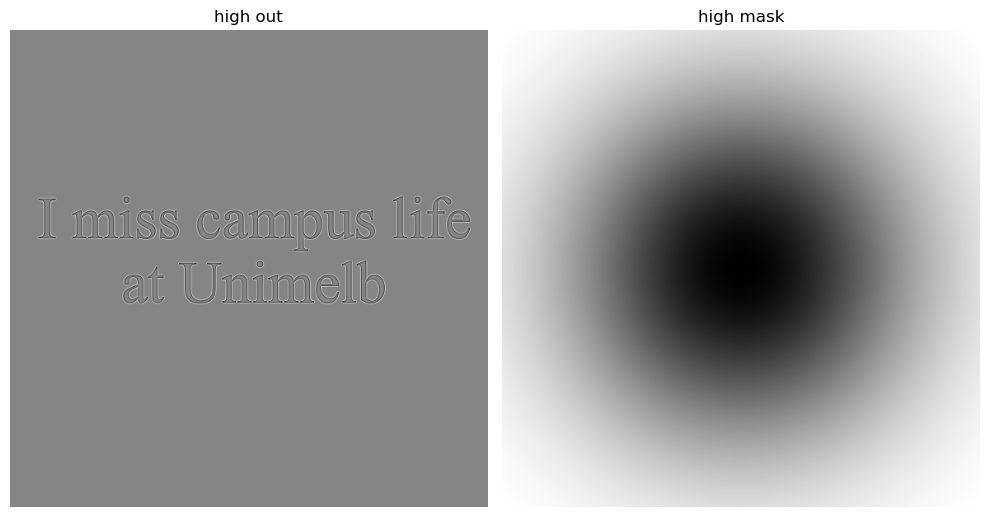

Threshold  200
MSE: 10.76, SSIM: 0.95 (data_range: 133.35)


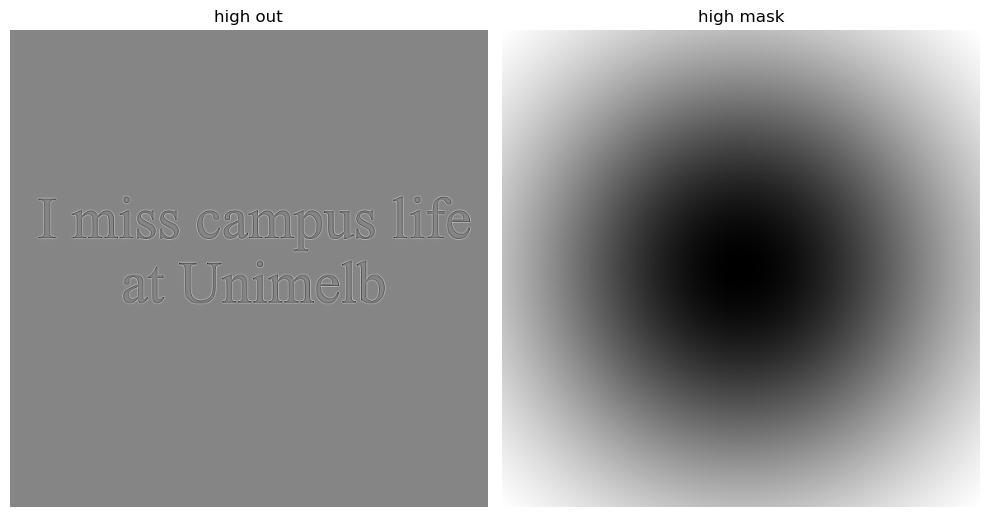

Threshold  500
MSE: 0.00, SSIM: 1.00 (data_range: 29.26)


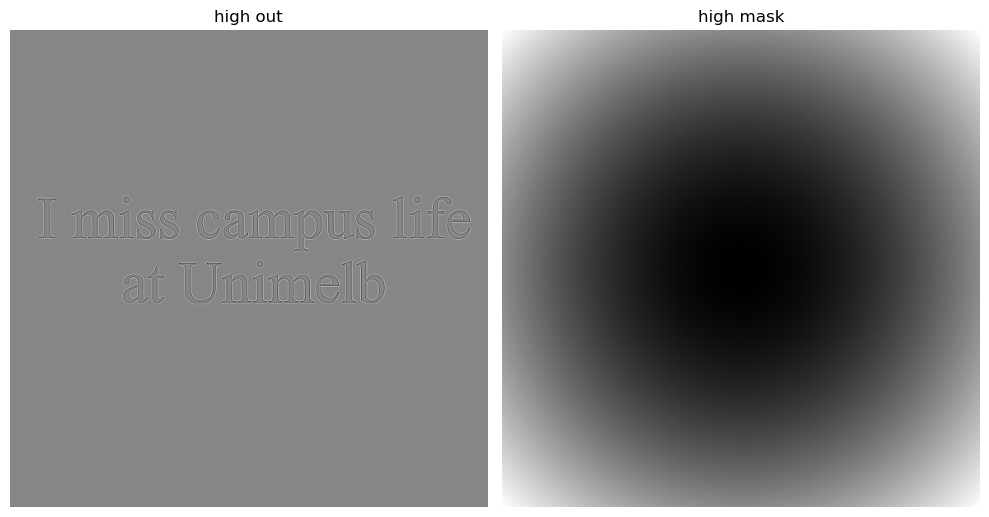

In [55]:
# visualise filtered image to select the best threshold
for t in thresholds_high:
    Images_HighPass(t)

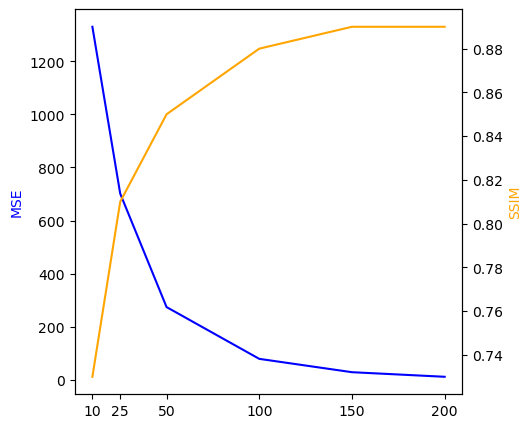

In [ ]:
# results from the previous step
mse_high = [1330.43, 701.40, 273.60, 78.34, 28.03, 10.76]
ssim_high = [0.73, 0.81, 0.85, 0.88, 0.89, 0.89]

fig,ax = plt.subplots()
ax.plot(thresholds_high[:-1], mse_high, color='blue')
ax.set_ylabel('MSE', color = 'blue')
ax2 = ax.twinx()
ax2.plot(thresholds_high[:-1], ssim_high, color='orange')
ax2.set_ylabel('SSIM', color = 'orange')
ax2.set_xticks(thresholds_high[:-1])

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: اعمال فیلتر پایین‌گذر بر پیش‌زمینه
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این قسمت قرار است که یک فیلتر پایین‌گذر گاوسی را بر تصویر پیش‌زمینه اعمال کنیم.  دقت کنید که فرکانس قطع را بدرستی انتخاب کنید. ممکن است پس از مراحل پایانی برای افزایش کیفیت به این مرحله بازگردید و فیلتر را با فرکانس قطع متفاوتی مجددا اعمال کنید.
<br>
این فیلتر جزئیات نرم و کلی تصویر را حفظ می‌کند، در حالی که جزئیات با فرکانس بالا را کاهش می‌دهد.
</font>
<br>
پیشنهاد می‌شود که از آستانه‌های پیشنهادی زیر برای این فیلتر پاین‌گذر استفاده کنید و از بین آن‌ها بهترین آستانه را انتخاب کنید:
</p>

$$\text{thresholds\_low} = [10, 50, 100, 250, 500]$$

#### Low Pass Filter 

In [57]:
# frequency thresholds 
thresholds_low = [10, 50, 100, 250, 500]

# Fourier transform 
f_l = np.fft.fft2(cover)
f_l = np.fft.fftshift(f_l)

In [58]:
def Images_LowPass(radius_low):
    f_low_filtered,mask_low = Gauss_LowPass(f_l,radius_low)

    # Invert Fourier transform to get the filtered image
    img_low = np.real(np.fft.ifft2(np.fft.fftshift(f_low_filtered)))
    
    # visualisation
    # visualisation setup
    fig,axs = plt.subplots(1,2)
    fig.set_figwidth(10)
    fig.set_figheight(10)
    
    print("Threshold ", radius_low)
    compare_images(cover, img_low)
    plt.subplot(1,2,1)
    plt.imshow(img_low ,cmap='gray')  
    plt.title('low out')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask_low ,cmap='gray')  
    plt.title('low mask')
    plt.axis('off')
    plt.show()


Threshold  10
MSE: 1470.56, SSIM: 0.43 (data_range: 255.00)


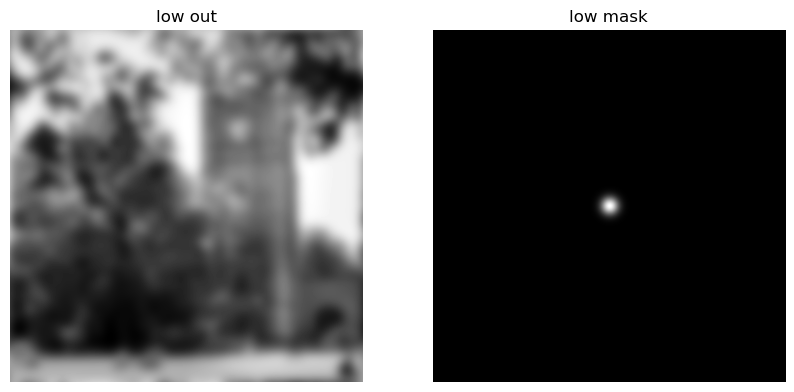

Threshold  50
MSE: 420.12, SSIM: 0.63 (data_range: 255.00)


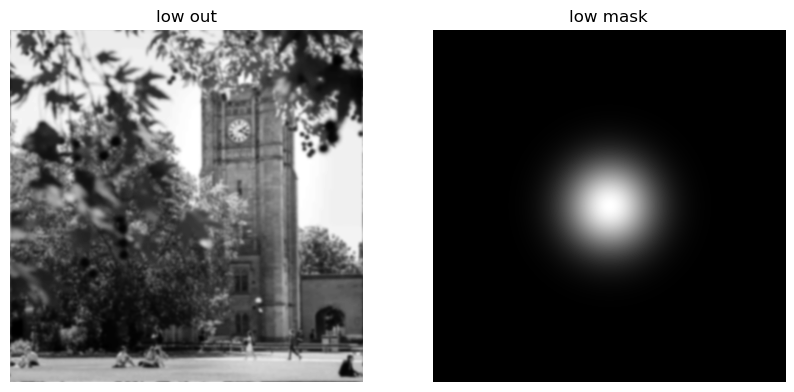

Threshold  100
MSE: 166.68, SSIM: 0.82 (data_range: 255.03)


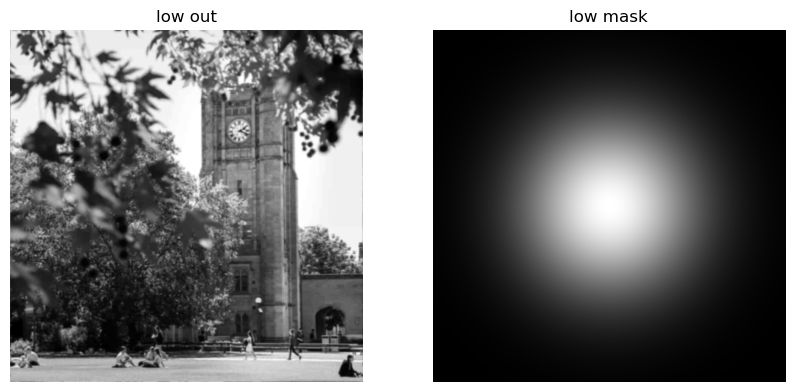

Threshold  250
MSE: 15.52, SSIM: 0.98 (data_range: 256.23)


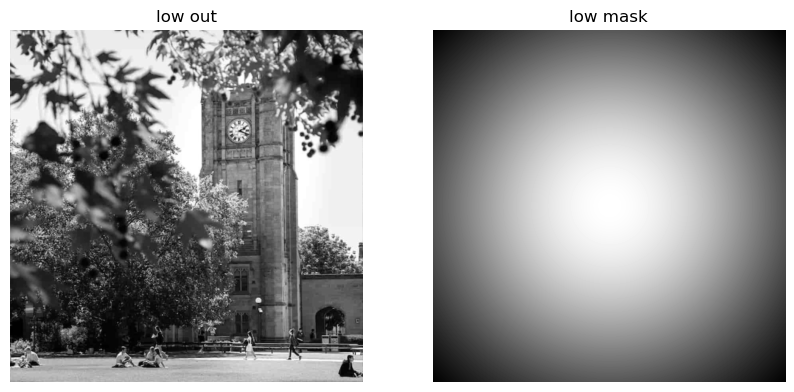

Threshold  500
MSE: 1.28, SSIM: 1.00 (data_range: 255.66)


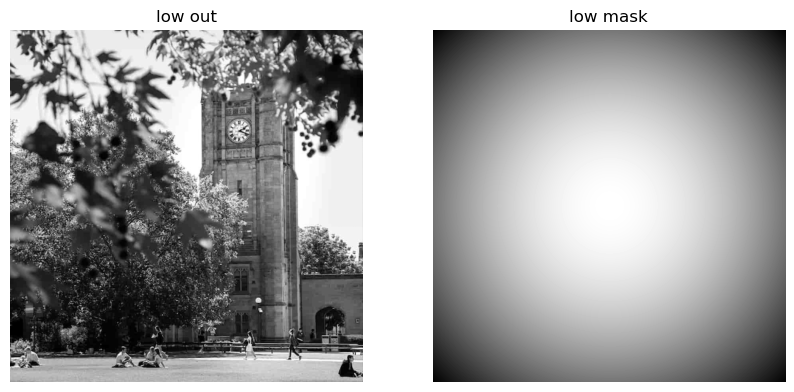

In [59]:
# visualise filtered image to select the best threshold
for t in thresholds_low:
    Images_LowPass(t)

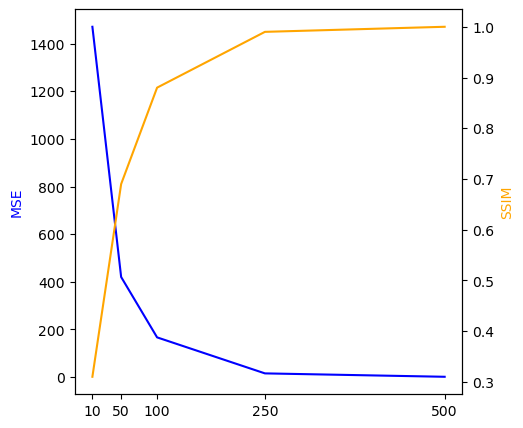

In [ ]:
# results from the previous step
mse_low = [1470.53, 420.11, 166.68, 15.52, 1.28 ]
ssim_low = [0.31, 0.69, 0.88, 0.99, 1.00]

fig,ax = plt.subplots()
ax.plot(thresholds_low, mse_low, color='blue')
ax.set_ylabel('MSE', color = 'blue')
ax2 = ax.twinx()
ax2.plot(thresholds_low, ssim_low, color='orange')
ax2.set_ylabel('SSIM', color = 'orange')
ax2.set_xticks(thresholds_low)

In [61]:
# apply the best thresholds to the images

best_radius_high = 150
f_high_filtered, mask_high = Gauss_HighPass(f_h, best_radius_high)

best_radius_low = 250
f_low_filtered, mask_low = Gauss_LowPass(f_l,best_radius_low)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله چهارم: ترکیب طیف‌های فرکانسی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله نوبت به آن می‌رسد که طیف‌های فرکانسی  که در مراحل قبلی محاسبه کرده بودیم را با یکدیگر ترکیب کنیم. 
<br>
ابتدا هر دو طیف فرکانسی را با یکدیگر جمع کنید. 
<br>
پس از جمع هر دو طیف فرکانسی، طیف فرکانسی تصویری بدست می‌آید که معادل است با طیف فرکانسی تصویری که متن و پیش‌زمینه با هم ترکیب شده‌اند. باید این طیف فرکانسی نهایی را از حوزه فرکانس به حوزه مکانی برگردانید.
</p>

In [62]:
# add them in Fourier domain and convert to spatial domain
result_image = np.real(np.fft.ifft2(np.fft.fftshift(f_low_filtered + f_high_filtered)))

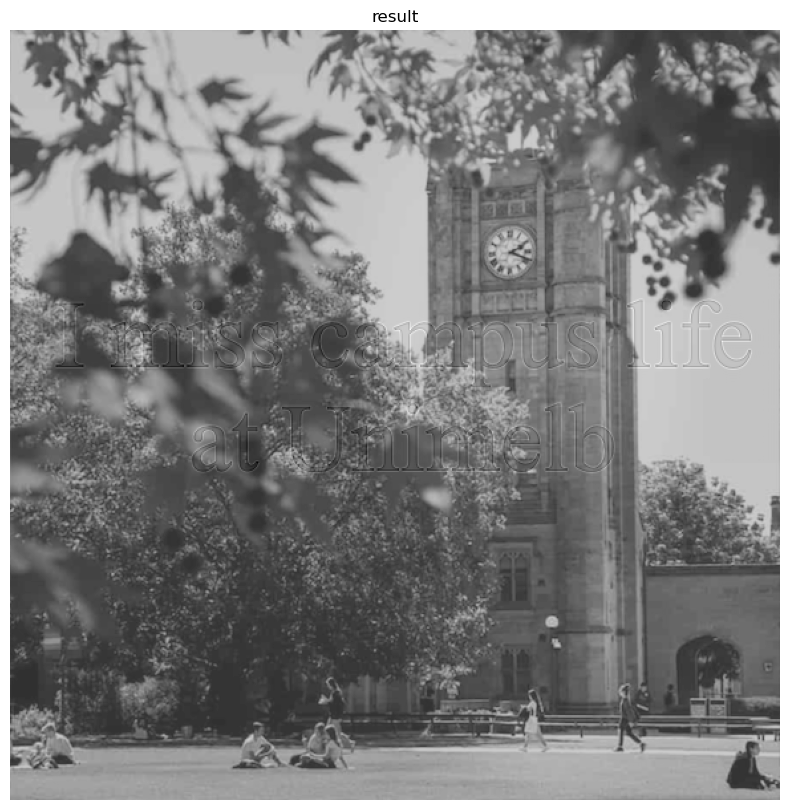

True

In [63]:
# visualise and save the final result image

plt.rcParams["figure.figsize"] = (10, 10)
plt.imshow(result_image ,cmap='gray')  
plt.title('result')
plt.axis('off')

plt.show()

cv2.imwrite("final_result.png", result_image) 


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پنجم: ذخیره‌سازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
حال در این مرحله، اگر تصویر ترکیب شده دارای کیفیت مناسب بود، این  تصویر نهایی را در کنار این نوت‌بوک ذخیره کنید. نام تصویر نهایی عبارت است از:
<br>
final_result.png
</p>

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پایانی: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [64]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "final_result.png"]
compress(file_names)

File Paths:
['notebook.ipynb', 'final_result.png']
